# Logistic Regression, Naive Bayse, Comparing the Decision Tree, KNN,

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [3]:
url = "https://raw.githubusercontent.com/abhishek18feb/Penguins-AI-ML/main/penguins.csv"

data = pd.read_csv(url)

print(data.head())

  species     island  bill_length_mm  ...  flipper_length_mm  body_mass_g     sex
0  Adelie  Torgersen            39.1  ...              181.0       3750.0    MALE
1  Adelie  Torgersen            39.5  ...              186.0       3800.0  FEMALE
2  Adelie  Torgersen            40.3  ...              195.0       3250.0  FEMALE
3  Adelie  Torgersen             NaN  ...                NaN          NaN     NaN
4  Adelie  Torgersen            36.7  ...              193.0       3450.0  FEMALE

[5 rows x 7 columns]


# Clean the data

In [4]:
data.dropna(inplace=True)

In [5]:
data.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


In [7]:
print(data.isna().sum())

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


In [8]:
data

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,FEMALE
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


In [21]:
df = pd.get_dummies(data, columns=['island', 'sex'])

In [22]:
df.head()

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island_Biscoe,island_Dream,island_Torgersen,sex_.,sex_FEMALE,sex_MALE
0,Adelie,39.1,18.7,181.0,3750.0,False,False,True,False,False,True
1,Adelie,39.5,17.4,186.0,3800.0,False,False,True,False,True,False
2,Adelie,40.3,18.0,195.0,3250.0,False,False,True,False,True,False
4,Adelie,36.7,19.3,193.0,3450.0,False,False,True,False,True,False
5,Adelie,39.3,20.6,190.0,3650.0,False,False,True,False,False,True


In [23]:
df

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island_Biscoe,island_Dream,island_Torgersen,sex_.,sex_FEMALE,sex_MALE
0,Adelie,39.1,18.7,181.0,3750.0,False,False,True,False,False,True
1,Adelie,39.5,17.4,186.0,3800.0,False,False,True,False,True,False
2,Adelie,40.3,18.0,195.0,3250.0,False,False,True,False,True,False
4,Adelie,36.7,19.3,193.0,3450.0,False,False,True,False,True,False
5,Adelie,39.3,20.6,190.0,3650.0,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
338,Gentoo,47.2,13.7,214.0,4925.0,True,False,False,False,True,False
340,Gentoo,46.8,14.3,215.0,4850.0,True,False,False,False,True,False
341,Gentoo,50.4,15.7,222.0,5750.0,True,False,False,False,False,True
342,Gentoo,45.2,14.8,212.0,5200.0,True,False,False,False,True,False


In [24]:
df.columns

Index(['species', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm',
       'body_mass_g', 'island_Biscoe', 'island_Dream', 'island_Torgersen',
       'sex_.', 'sex_FEMALE', 'sex_MALE'],
      dtype='object')

In [25]:
processed_df = df.drop("sex_.", axis=1)

In [26]:
processed_df

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island_Biscoe,island_Dream,island_Torgersen,sex_FEMALE,sex_MALE
0,Adelie,39.1,18.7,181.0,3750.0,False,False,True,False,True
1,Adelie,39.5,17.4,186.0,3800.0,False,False,True,True,False
2,Adelie,40.3,18.0,195.0,3250.0,False,False,True,True,False
4,Adelie,36.7,19.3,193.0,3450.0,False,False,True,True,False
5,Adelie,39.3,20.6,190.0,3650.0,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...
338,Gentoo,47.2,13.7,214.0,4925.0,True,False,False,True,False
340,Gentoo,46.8,14.3,215.0,4850.0,True,False,False,True,False
341,Gentoo,50.4,15.7,222.0,5750.0,True,False,False,False,True
342,Gentoo,45.2,14.8,212.0,5200.0,True,False,False,True,False


In [27]:
print(processed_df["species"].unique())

['Adelie' 'Chinstrap' 'Gentoo']


In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

processed_df["species"] = le.fit_transform(processed_df["species"])

processed_df

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island_Biscoe,island_Dream,island_Torgersen,sex_FEMALE,sex_MALE
0,0,39.1,18.7,181.0,3750.0,False,False,True,False,True
1,0,39.5,17.4,186.0,3800.0,False,False,True,True,False
2,0,40.3,18.0,195.0,3250.0,False,False,True,True,False
4,0,36.7,19.3,193.0,3450.0,False,False,True,True,False
5,0,39.3,20.6,190.0,3650.0,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...
338,2,47.2,13.7,214.0,4925.0,True,False,False,True,False
340,2,46.8,14.3,215.0,4850.0,True,False,False,True,False
341,2,50.4,15.7,222.0,5750.0,True,False,False,False,True
342,2,45.2,14.8,212.0,5200.0,True,False,False,True,False


In [29]:
print(le.classes_)

['Adelie' 'Chinstrap' 'Gentoo']


In [47]:
target_classes = le.classes_

Now Split the dataset in to target and feature

In [30]:
X = processed_df.drop(columns=['species'], axis=1)
y = processed_df['species']

In [31]:
X

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island_Biscoe,island_Dream,island_Torgersen,sex_FEMALE,sex_MALE
0,39.1,18.7,181.0,3750.0,False,False,True,False,True
1,39.5,17.4,186.0,3800.0,False,False,True,True,False
2,40.3,18.0,195.0,3250.0,False,False,True,True,False
4,36.7,19.3,193.0,3450.0,False,False,True,True,False
5,39.3,20.6,190.0,3650.0,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...
338,47.2,13.7,214.0,4925.0,True,False,False,True,False
340,46.8,14.3,215.0,4850.0,True,False,False,True,False
341,50.4,15.7,222.0,5750.0,True,False,False,False,True
342,45.2,14.8,212.0,5200.0,True,False,False,True,False


In [32]:
y

,species
0,0
1,0
2,0
4,0
5,0
...,...
338,2
340,2
341,2
342,2


# Logistic Regression

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Split the data in train and test set

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling the data

In [38]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [41]:
X_train

array([[-0.59644741, -1.74305279,  0.92164858, ..., -0.37553381,
         1.04208325, -1.03429563],
       [-1.26580555,  0.32761448, -0.72413331, ..., -0.37553381,
         1.04208325, -1.03429563],
       [ 1.09554123, -0.63196304,  1.63720593, ..., -0.37553381,
        -0.95961623,  0.96684156],
       ...,
       [-0.81956679,  0.2771104 , -0.58102184, ..., -0.37553381,
         1.04208325, -1.03429563],
       [ 0.25884355, -1.08649975,  1.35098299, ..., -0.37553381,
        -0.95961623,  0.96684156],
       [-1.11705929, -0.07641816, -1.43969066, ..., -0.37553381,
         1.04208325, -1.03429563]])

In [39]:
lrmodel = LogisticRegression(max_iter=1000)
lrmodel.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [42]:
y_pred = lrmodel.predict(X_test)

In [44]:
y_pred

array([0, 2, 0, 1, 0, 2, 2, 1, 1, 1, 0, 0, 2, 0, 2, 0, 0, 1, 0, 2, 0, 0,
       2, 1, 0, 0, 2, 2, 1, 2, 1, 2, 0, 0, 2, 2, 1, 2, 0, 0, 0, 0, 1, 1,
       0, 0, 2, 0, 0, 2, 0, 2, 2, 0, 0, 2, 0, 0, 1, 1, 2, 2, 2, 0, 0, 2,
       0])

# Accuracy

In [46]:
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

Accuracy Score: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        23

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



# Confusion Matrix

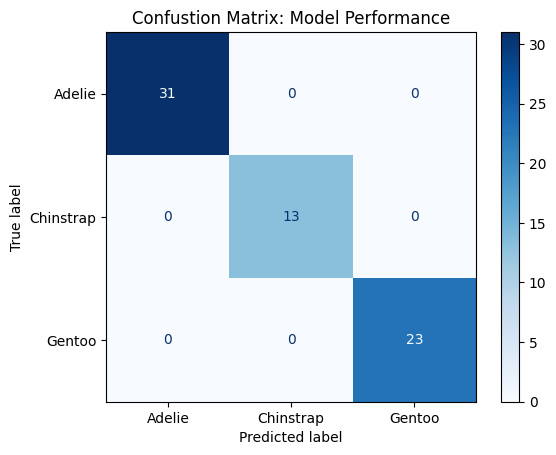

In [48]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_classes)
# 3. Plot darw karna
display.plot(cmap=plt.cm.Blues) # Blues color theme use ki hai
plt.title("Confustion Matrix: Model Performance")
plt.show()

# Naive Bayes Algorithm

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [60]:
# Picking X and y from the above
X = processed_df.drop(columns=['species'], axis=1)
y = processed_df['species']

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [62]:
gsmodel = GaussianNB()
gsmodel.fit(X_train, y_train)

GaussianNB()

In [63]:
y_pred = gsmodel.predict(X_test)

In [64]:
y_pred

array([1, 2, 0, 1, 0, 2, 2, 1, 1, 1, 0, 0, 2, 1, 2, 1, 0, 1, 0, 2, 0, 1,
       2, 1, 0, 0, 2, 2, 1, 2, 1, 2, 0, 1, 2, 2, 1, 2, 0, 0, 1, 1, 1, 1,
       0, 0, 2, 0, 0, 2, 0, 2, 2, 0, 0, 2, 0, 0, 1, 1, 2, 2, 2, 0, 0, 2,
       0])

# Accuracy

In [65]:
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.8955
              precision    recall  f1-score   support

           0       1.00      0.77      0.87        31
           1       0.65      1.00      0.79        13
           2       1.00      1.00      1.00        23

    accuracy                           0.90        67
   macro avg       0.88      0.92      0.89        67
weighted avg       0.93      0.90      0.90        67



# Confusion Matrix

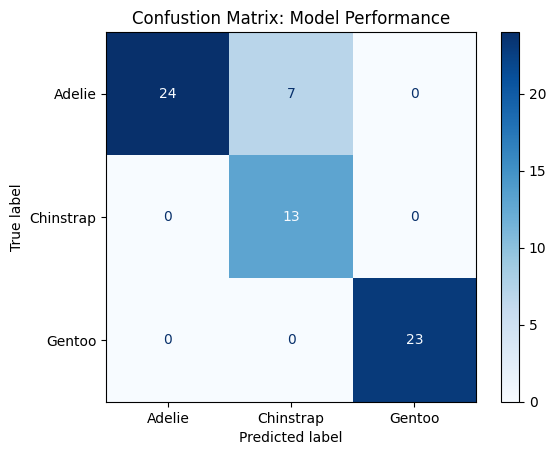

In [66]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_classes)
# 3. Plot darw karna
display.plot(cmap=plt.cm.Blues) # Blues color theme use ki hai
plt.title("Confustion Matrix: Model Performance")
plt.show()

# Let's check the accuracy of Same code with Scaling

In [67]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [68]:
gsmodel_with_scale_data = GaussianNB()
gsmodel_with_scale_data.fit(X_train, y_train)

GaussianNB()

In [72]:
y_pred_scale = gsmodel_with_scale_data.predict(X_test)

In [73]:
print(f"Accuracy Score while scaling: {accuracy_score(y_test, y_pred_scale):.4f}")
print(classification_report(y_test, y_pred_scale))

Accuracy Score while scaling: 0.7612
              precision    recall  f1-score   support

           0       1.00      0.48      0.65        31
           1       0.65      1.00      0.79        13
           2       0.72      1.00      0.84        23

    accuracy                           0.76        67
   macro avg       0.79      0.83      0.76        67
weighted avg       0.84      0.76      0.74        67



# Confusion Matrix

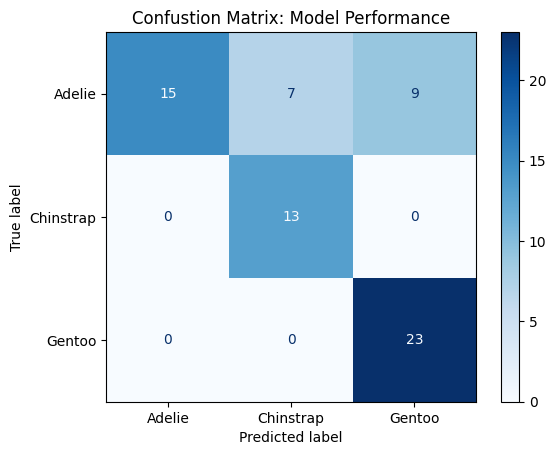

In [74]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_scale)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_classes)
# 3. Plot darw karna
display.plot(cmap=plt.cm.Blues) # Blues color theme use ki hai
plt.title("Confustion Matrix: Model Performance")
plt.show()

# KNN Algorithm

In [75]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

In [86]:
knmodel = KNeighborsClassifier(n_neighbors=3)
knmodel.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [87]:
y_pred = knmodel.predict(X_test)

In [88]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 80.60%


# Let's test after scaling

In [89]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [90]:
kn_scale_model = KNeighborsClassifier(n_neighbors=3)
kn_scale_model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [91]:
y_scale_pred = kn_scale_model.predict(X_test)

In [93]:
accuracy = accuracy_score(y_test, y_scale_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 98.51%


# Confusion Matrix after scaling data

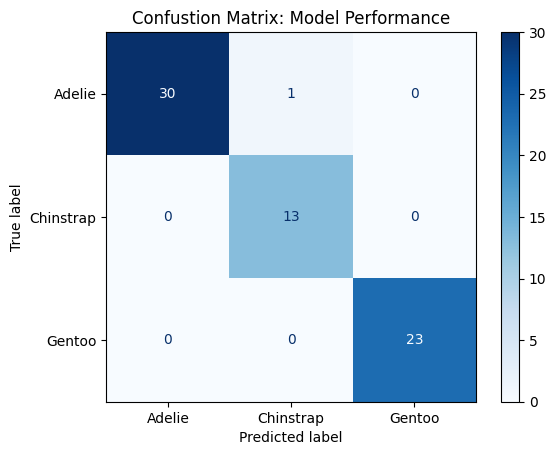

In [94]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_scale_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_classes)
# 3. Plot darw karna
display.plot(cmap=plt.cm.Blues) # Blues color theme use ki hai
plt.title("Confustion Matrix: Model Performance")
plt.show()

# Decision Tree Algorithm

In [95]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

In [96]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [97]:
decision_model = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)

In [98]:
decision_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [99]:
y_dec_pred = decision_model.predict(X_test)

In [100]:
accuracy = accuracy_score(y_test, y_dec_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 98.51%


In [101]:
decision_model = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

In [102]:
decision_model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

In [104]:
y_dec_pred_entropy = decision_model.predict(X_test)

In [105]:
accuracy = accuracy_score(y_test, y_dec_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 98.51%


# Let's check after appying scaling

In [106]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [107]:
decision_model_scaling = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

In [109]:
decision_model_scaling.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

In [110]:
y_dec_pred_entropy_with_scale_data = decision_model_scaling.predict(X_test)

In [111]:
accuracy = accuracy_score(y_test, y_dec_pred_entropy_with_scale_data)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 100.00%


# Confusion Matrix after scaling the data

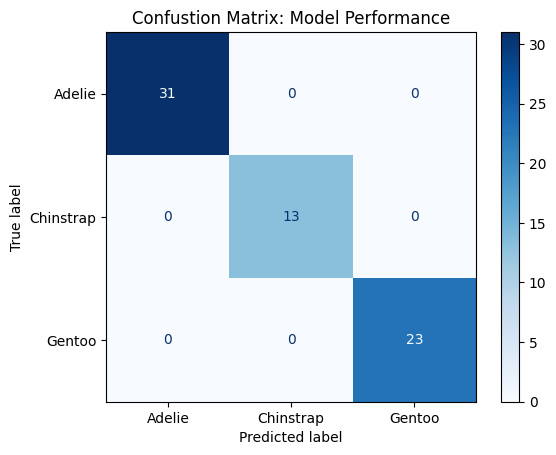

In [112]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_dec_pred_entropy_with_scale_data)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_classes)
# 3. Plot darw karna
display.plot(cmap=plt.cm.Blues) # Blues color theme use ki hai
plt.title("Confustion Matrix: Model Performance")
plt.show()